In [1]:
import os
import json
import re
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

from sentence_transformers import util

import matplotlib.pyplot as plt

#Text cleaning
fig_patterns = [
    re.compile(r'\bFig\.(?=\d)'),
    re.compile(r'\bet al\.'),
    re.compile(r'\bFig\.\s([A-Z])'),
    re.compile(r'\bFig\.\s(\d)\((\w)\)'),
    re.compile(r'\bFig\.\s(\d)')
]

def normalize_text(text):
    text = fig_patterns[0].sub('Fig', text)
    text = fig_patterns[1].sub('et al', text)
    text = fig_patterns[2].sub(r'Fig \1', text)
    text = fig_patterns[3].sub(r'Fig \1(\2)', text)
    text = fig_patterns[4].sub(r'Fig \1', text)
    return text

def extract_sections_from_json(json_file_path):
    """
    Extract and clean sections from a BioC JSON file, skips 'title_1' section headers.
    Returns a dictionary with section types as keys and cleaned merged text as values.
    """
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    merged_sections = defaultdict(str)

    for document in data[0].get('documents', []):
        section_texts = defaultdict(list)

        for passage in document.get('passages', []):
            # Skip "title_1" headers bcs they only have the title of the section
            if passage.get('infons', {}).get('type') == 'title_1':
                continue

            section_type = passage.get('infons', {}).get('section_type', '').upper()
            text = passage.get('text', '')
            if section_type in ['METHODS', 'INTRO', 'RESULTS', 'DISCUSS']:
                cleaned_text = normalize_text(text)
                section_texts[section_type].append(cleaned_text)

        for section_type, texts in section_texts.items():
            merged_sections[section_type] = ' '.join(texts)

    return merged_sections


#Process all papers
def process_directory(directory_path):
    papers_sections = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.json'):
            file_path = os.path.join(directory_path, filename)
            merged_sections = extract_sections_from_json(file_path)
            papers_sections.append(merged_sections)
    return papers_sections

#Build ground truth
def build_ground_truth(papers_sections):
    ground_truth = {'methods': [], 'intro': [], 'results': [], 'discuss': []}
    for paper in papers_sections:
        ground_truth['intro'].append(paper.get('INTRO', ''))
        ground_truth['methods'].append(paper.get('METHODS', ''))
        ground_truth['results'].append(paper.get('RESULTS', ''))
        ground_truth['discuss'].append(paper.get('DISCUSS', ''))
    return ground_truth



/home/naji01/miniconda3/envs/ip-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Run making the text data
papers_sections = process_directory("./")
ground_truth = build_ground_truth(papers_sections)

In [ ]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')

#Embed the ground truth
ground_embeddings = {section: model.encode(texts, convert_to_tensor=True) for section, texts in ground_truth.items()}


In [ ]:
similarity_distributions = {}
section_keys = list(ground_embeddings.keys())

for i, s1 in enumerate(section_keys):
    for j, s2 in enumerate(section_keys):
        if j < i:
            continue  #avoid duplicate pairs

        emb1 = ground_embeddings[s1]
        emb2 = ground_embeddings[s2]

        #Compute all pairwise cosine similarities
        sim_matrix = util.pytorch_cos_sim(emb1, emb2)

        #Flatten similarity matrix to a list
        similarities = sim_matrix.flatten().tolist()
        similarity_distributions[(s1, s2)] = similarities




In [ ]:


def plot_similarity_distributions(similarity_distributions, focus_sections=None):
    """
    Plots histograms for selected section pairs.
    If focus_sections is provided, only show those pairs.
    """
    for (sec1, sec2), sims in similarity_distributions.items():
        if focus_sections and (sec1 not in focus_sections and sec2 not in focus_sections):
            continue

        plt.figure(figsize=(6, 4))
        plt.hist(sims, bins=50, alpha=0.7, color='skyblue')
        plt.title(f'Similarity Distribution: {sec1} vs {sec2}')
        plt.xlabel('Cosine Similarity')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()


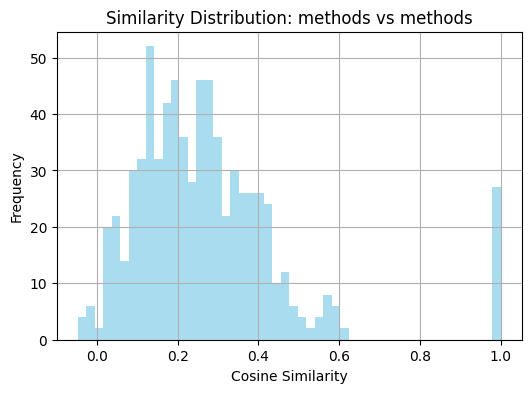

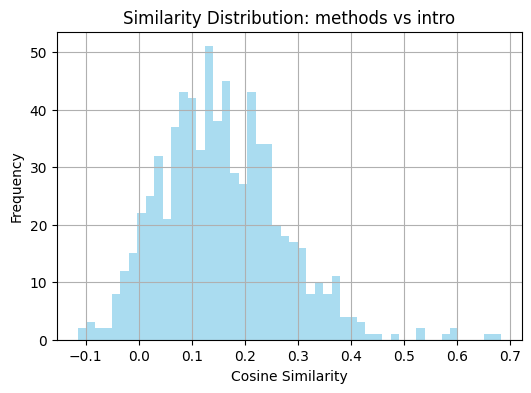

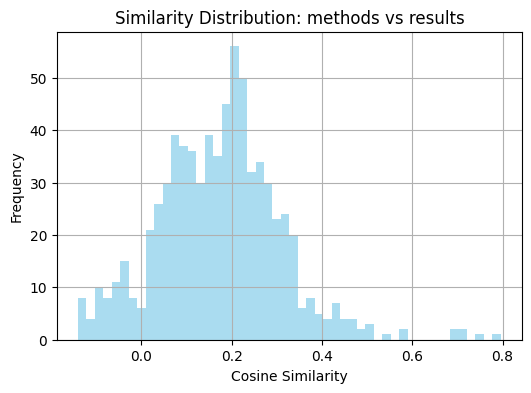

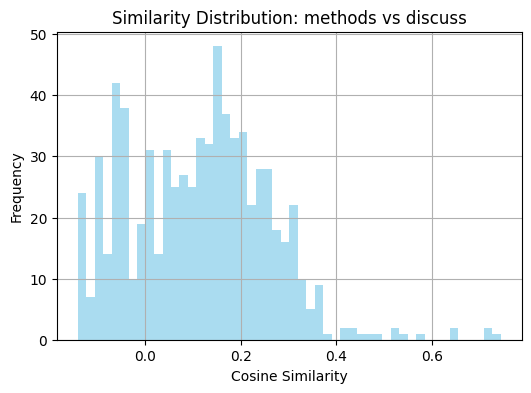

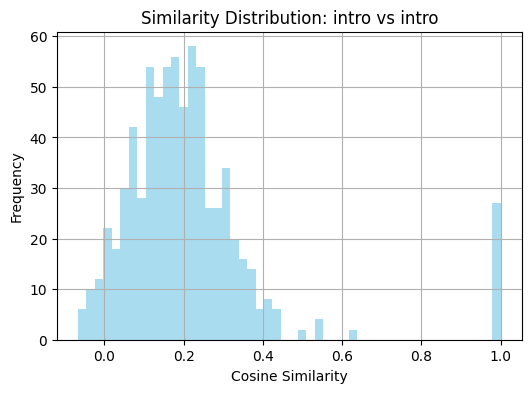

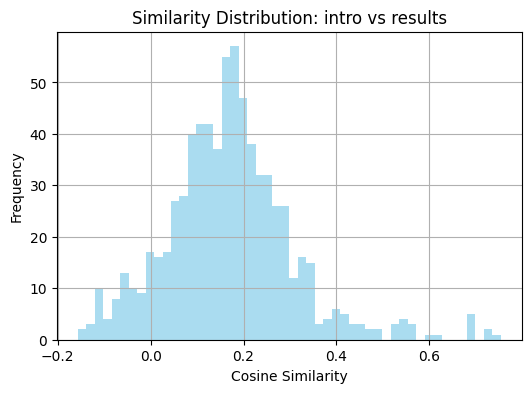

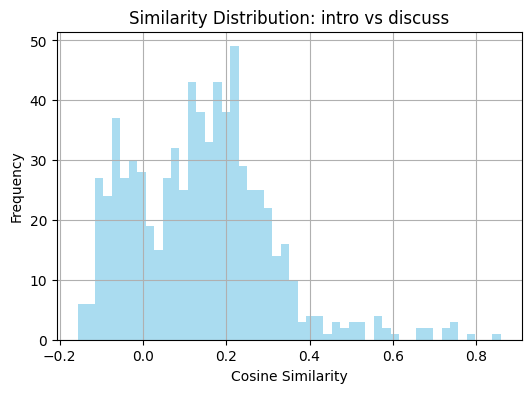

In [ ]:
plot_similarity_distributions(similarity_distributions, focus_sections=['intro', 'methods'])


## K-NN clasiifier for section prediction

In [ ]:


texts = []
labels = []

for section, section_texts in ground_truth.items():
    texts.extend(section_texts)
    labels.extend([section] * len(section_texts))

#Encode texts
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts)

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, stratify=labels, random_state=42#anything really
)

#Train k-NN
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(X_train, y_train)

#Predict
y_pred = knn.predict(X_test)

#Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     discuss       0.31      0.50      0.38         8
       intro       0.38      0.38      0.38         8
     methods       0.89      0.89      0.89         9
     results       0.33      0.12      0.18         8

    accuracy                           0.48        33
   macro avg       0.48      0.47      0.46        33
weighted avg       0.49      0.48      0.47        33



In [5]:


texts = []
labels = []

for section, section_texts in ground_truth.items():
    texts.extend(section_texts)
    labels.extend([section] * len(section_texts))

#Encode texts
model = SentenceTransformer("microsoft/biogpt")
embeddings = model.encode(texts)

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, stratify=labels, random_state=42
)

#Train k-NN
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(X_train, y_train)

#Predict
y_pred = knn.predict(X_test)

#Report
print(classification_report(y_test, y_pred))


No sentence-transformers model found with name microsoft/biogpt. Creating a new one with mean pooling.


              precision    recall  f1-score   support

     discuss       0.29      0.50      0.36         8
       intro       0.43      0.38      0.40         8
     methods       0.90      1.00      0.95         9
     results       1.00      0.25      0.40         8

    accuracy                           0.55        33
   macro avg       0.65      0.53      0.53        33
weighted avg       0.66      0.55      0.54        33



In [4]:


texts = []
labels = []

for section, section_texts in ground_truth.items():
    texts.extend(section_texts)
    labels.extend([section] * len(section_texts))

#Encode texts
model = SentenceTransformer("microsoft/biogpt")
embeddings = model.encode(texts)

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, stratify=labels, random_state=42
)

#Train k-NN
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

#Predict
y_pred = knn.predict(X_test)

#Report
print(classification_report(y_test, y_pred))

No sentence-transformers model found with name microsoft/biogpt. Creating a new one with mean pooling.


              precision    recall  f1-score   support

     discuss       0.27      0.38      0.32         8
       intro       0.40      0.50      0.44         8
     methods       0.90      1.00      0.95         9
     results       1.00      0.25      0.40         8

    accuracy                           0.55        33
   macro avg       0.64      0.53      0.53        33
weighted avg       0.65      0.55      0.54        33

